In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os 

root = os.getcwd()
path_plot = "/home/peiretti/fair-clustering/plots/yelp"
matrix = np.load(root + "/matrix.npy").astype(int)
Sx = np.load(root + "/gender.npy").astype(int)
categories = np.load(root + "/restaurant_type.npy").astype(int)

genders, counts = np.unique(Sx, return_counts=True)
gender_labels = ["Male", "Female"]

# invert dictionary: id -> category name
category_str = np.load(root + "/restaurant_type_str.npy", allow_pickle=True) 
dict_category = dict(zip(category_str, categories))
id_to_category = {v: k for k, v in dict_category.items()}
unique_categories = np.unique(categories)
category_labels = [id_to_category[c] for c in unique_categories]

In [9]:
likes = (matrix >= 3).astype(int)

pref = np.zeros((2, len(unique_categories)))

for g in [0, 1]:

    users = (Sx == g)

    group_likes = likes[users]

    restaurant_likes = group_likes.sum(axis=0)

    cat_likes = np.array([
        restaurant_likes[categories == c].sum()
        for c in unique_categories
    ])

    pref[g] = cat_likes / cat_likes.sum()

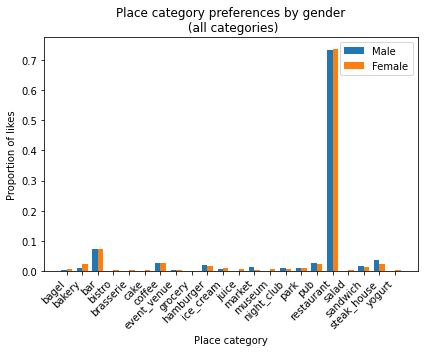

In [10]:
x = np.arange(len(unique_categories))
width = 0.35

plt.figure(figsize=(6,5))

plt.bar(x - width/2, pref[0], width, label="Male")
plt.bar(x + width/2, pref[1], width, label="Female")

plt.xticks(x, category_labels, rotation=45, ha="right")
plt.ylabel("Proportion of likes")
plt.xlabel("Place category")
plt.title("Place category preferences by gender\n (all categories)")
plt.legend()

plt.tight_layout()
plt.savefig(path_plot + "/yelp_category_preferences_gender.png", dpi=300)
plt.show()

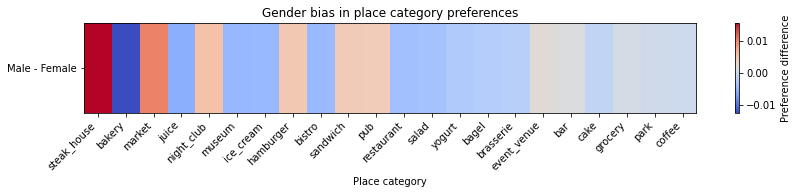

In [4]:
for g in [0, 1]:
    user_mask = (Sx == g)
    group_likes = likes[user_mask]                    # users in group g x restaurants
    restaurant_likes = group_likes.sum(axis=0)       # total likes per restaurant

    cat_likes = np.array([
        restaurant_likes[categories == c].sum()
        for c in unique_categories
    ], dtype=float)

    total_likes = cat_likes.sum()
    if total_likes > 0:
        pref[g] = cat_likes / total_likes

# ----------------------------
# Bias score: male - female
# ----------------------------
bias = pref[0] - pref[1]

# sort categories by absolute difference
order = np.argsort(np.abs(bias))[::-1]

bias = bias[order]
category_labels = [category_labels[i] for i in order]

# ----------------------------
# Plot heatmap
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 2.8))

heat = ax.imshow(bias[np.newaxis, :], aspect='auto', cmap='coolwarm')

ax.set_xticks(np.arange(len(category_labels)))
ax.set_xticklabels(category_labels, rotation=45, ha='right')
ax.set_yticks([0])
ax.set_yticklabels(['Male - Female'])
ax.set_xlabel("Place category")
ax.set_title("Gender bias in place category preferences")

cbar = plt.colorbar(heat, ax=ax)
cbar.set_label("Preference difference")

plt.tight_layout()
#plt.savefig("yelp_gender_bias_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

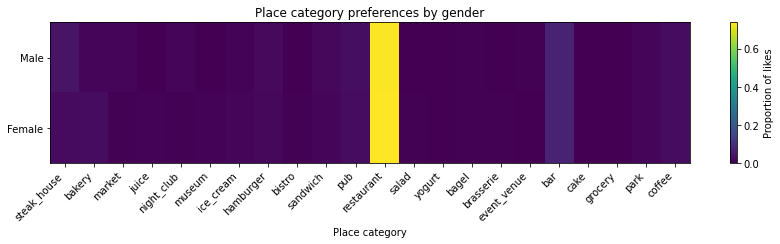

In [5]:
plot_pref = pref[:, order]

fig, ax = plt.subplots(figsize=(12, 3.5))

heat = ax.imshow(plot_pref, aspect='auto', cmap='viridis')

ax.set_xticks(np.arange(len(category_labels)))
ax.set_xticklabels(category_labels, rotation=45, ha='right')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Male', 'Female'])
ax.set_xlabel("Place category")
ax.set_title("Place category preferences by gender")

cbar = plt.colorbar(heat, ax=ax)
cbar.set_label("Proportion of likes")

plt.tight_layout()
plt.savefig(path_plot + "/yelp_gender_preferences_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

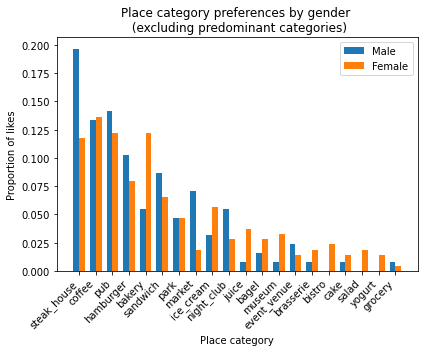

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- likes definition ---
likes = (matrix >= 3).astype(int)

# --- invert dictionary: id -> category name ---
id_to_category = {v: k for k, v in dict_category.items()}

unique_categories = np.unique(categories)
category_labels = np.array([id_to_category[c] for c in unique_categories])

# -----------------------------
# Remove dominant category
# -----------------------------

#dominant_category = "restaurant"
#mask = category_labels != dominant_category

excluded_categories = ["restaurant", "bar"]
mask = ~np.isin(category_labels, excluded_categories)

filtered_categories = unique_categories[mask]
category_labels = category_labels[mask]

# -----------------------------
# Compute normalized preferences
# -----------------------------
pref = np.zeros((2, len(filtered_categories)))

for g in [0, 1]:

    users = (Sx == g)

    group_likes = likes[users]

    restaurant_likes = group_likes.sum(axis=0)

    cat_likes = np.array([
        restaurant_likes[categories == c].sum()
        for c in filtered_categories
    ])

    pref[g] = cat_likes / cat_likes.sum()

# -----------------------------
# Sort categories for readability
# -----------------------------
order = np.argsort(pref.sum(axis=0))[::-1]

pref = pref[:, order]
category_labels = category_labels[order]

# -----------------------------
# Plot
# -----------------------------
x = np.arange(len(category_labels))
width = 0.35

plt.figure(figsize=(6,5))

plt.bar(x - width/2, pref[0], width, label="Male")
plt.bar(x + width/2, pref[1], width, label="Female")

plt.xticks(x, category_labels, rotation=45, ha="right")
plt.ylabel("Proportion of likes")
plt.xlabel("Place category")

plt.title("Place category preferences by gender \n (excluding predominant categories)")
plt.legend()

plt.tight_layout()
plt.savefig(path_plot + "/yelp_gender_preferences_no_dominant.png", dpi=300)
plt.show()

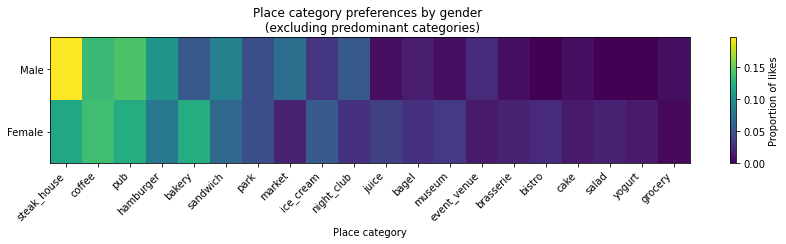

In [7]:
fig, ax = plt.subplots(figsize=(12, 3.5))

heat = ax.imshow(pref, aspect='auto', cmap='viridis')

ax.set_xticks(np.arange(len(category_labels)))
ax.set_xticklabels(category_labels, rotation=45, ha='right')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Male', 'Female'])
ax.set_xlabel("Place category")
ax.set_title("Place category preferences by gender \n (excluding predominant categories)")

cbar = plt.colorbar(heat, ax=ax)
cbar.set_label("Proportion of likes")

plt.tight_layout()
plt.savefig(path_plot + "/yelp_gender_preferences_heatmap_no_dominated.png", dpi=300, bbox_inches="tight")
plt.show()